In [38]:
import sklearn
print(sklearn.__version__)

1.7.2


In [3]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shahe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shahe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shahe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# load data
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

In [5]:
# Add labels
fake["label"] = 0
real["label"] = 1

In [6]:
# combine
df = pd.concat([fake, real], ignore_index=True)
df.shape

(44898, 5)

In [7]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


### Text Preprocessing

In [8]:
def preprocess(text):
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove punctuations
    text = re.sub(r"[^a-z\s]", "", text)

    # Remove html
    text = re.sub(r"<.*?>" , "", text)
    return text

df["content"] = df["title"] + "" + df["text"]
df["content"] = df["content"].apply(preprocess)

In [9]:
# Remove stopword
def remove_stopword(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))

    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["content"] = df["content"].apply(remove_stopword)

In [11]:
df['content'][3]

'trump obsessed even obamas name coded website imageson christmas day donald trump announced would back work following day golfing fourth day row former reality show star blasted former president barack obama playing golf trump track outpace number golf games predecessor playedupdated tracker trump appearances trump properties rounds golf including today pace pass obama firstterm total july next year pictwittercomgemcjqtbh philip bump pbump december makes washington post reporter discovered trump website really weird everything administration bizarre af coding contained reference obama golf unlike obama working fix problem golf course however coding done correctlythe website donald trump spent several days row golf course coded serve following message event internal server error pictwittercomwiqsqnnzw christopher ingraham cingraham december snippet code appears pages footer says paid rnc pictwittercomoazdtb christopher ingraham cingraham december also others noted thread weird code cle

In [13]:
# Stemming
from nltk.stem import PorterStemmer

def stemming(text):
    stemmer = PorterStemmer()
    tokens = word_tokenize(text)

    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

df["content"] = df["content"].apply(stemming)

In [14]:
df["content"][3]

'trump obsess even obama name code websit imageson christma day donald trump announc would back work follow day golf fourth day row former realiti show star blast former presid barack obama play golf trump track outpac number golf game predecessor playedupd tracker trump appear trump properti round golf includ today pace pass obama firstterm total juli next year pictwittercomgemcjqtbh philip bump pbump decemb make washington post report discov trump websit realli weird everyth administr bizarr af code contain refer obama golf unlik obama work fix problem golf cours howev code done correctlyth websit donald trump spent sever day row golf cours code serv follow messag event intern server error pictwittercomwiqsqnnzw christoph ingraham cingraham decemb snippet code appear page footer say paid rnc pictwittercomoazdtb christoph ingraham cingraham decemb also other note thread weird code clear would ever actual display know christoph ingraham cingraham decemb code call refer obama deletedupd

# TF-IDF Vectorization

In [33]:
X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(35918, 5000)


# Train Model

In [34]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
print("Training done")

Training done


# Evaluation

Accuracy: 0.9853006681514477
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4733
        Real       0.98      0.99      0.98      4247

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



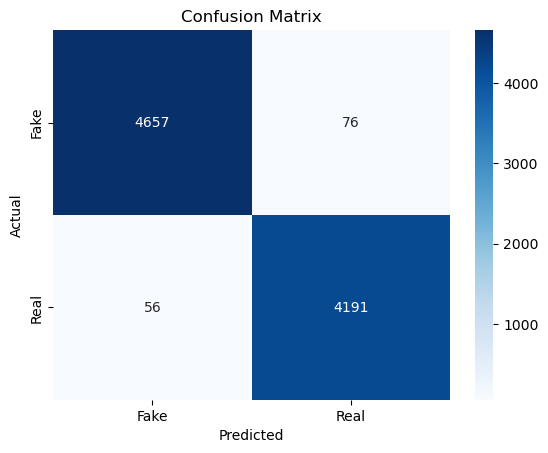

In [22]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Save Model

In [35]:
import joblib
import os
save_path = r"C:\Users\shahe\Machine Learning\NLP\Fake News Detector"
joblib.dump(vectorizer, os.path.join(save_path, 'vectorizer.pkl'))
joblib.dump(model, os.path.join(save_path, 'model.pkl'))
print("Saved to:", save_path)

Saved to: C:\Users\shahe\Machine Learning\NLP\Fake News Detector


In [26]:
# Load and test right here in notebook
test_vectorizer = joblib.load('vectorizer.pkl')
test_result = test_vectorizer.transform(["this is a test sentence"])
print(test_result.shape)  # Should print (1, 5000)

(1, 5000)


In [32]:
import os
print(os.getcwd())

C:\Users\shahe\Machine Learning\NLP\Fake News Detector


In [36]:
test = joblib.load(r"C:\Users\shahe\Machine Learning\NLP\Fake News Detector\vectorizer.pkl")
print(hasattr(test, 'idf_'))  # Must print True

True


In [37]:
import joblib

# Load the exact file
v = joblib.load(r"C:\Users\shahe\Machine Learning\NLP\Fake News Detector\vectorizer.pkl")
print(type(v))
print(hasattr(v, 'idf_'))

# Transform a test sentence
result = v.transform(["this is a test"])
print(result.shape)

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
True
(1, 5000)
